# Tarea Examen 1

Nombre: **Ana Karina Espinoza Candia**

### Física Computacional 2026-2

Resuelva los siguientes ejercicios.

1. Genere una función que se llame ```mi_plot(x,y,gap=1,label=" ")``` que haga la gráfica de una función no contínua y que no dibuje una línea vertical. Para ello utilice el parámetro ```gap``` para indicar cual sería la mínima discontinuidad que se debe tomar en cuenta para que el graficador no realice la línea vertical. Verifique el funcionamiento de su función con 3 ejemplos.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def mi_plot(x, y, gap=1, label=" "):
    x = np.array(x)
    y = np.array(y)
    y_plot = y.copy()
    for i in range(len(y) - 1):
        if abs(y[i+1] - y[i]) > gap:
            y_plot[i+1] = np.nan  

    # Graficar
    plt.plot(x, y_plot, label=label)
    plt.legend()
    plt.grid()

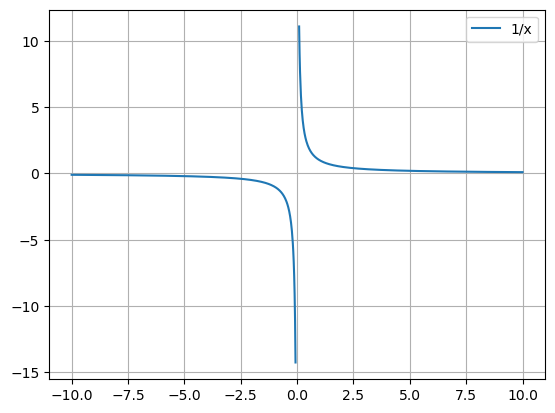

In [2]:
x = np.linspace(-10, 10, 1000)
y = 1/x

mi_plot(x, y, gap=5, label="1/x")
plt.show()

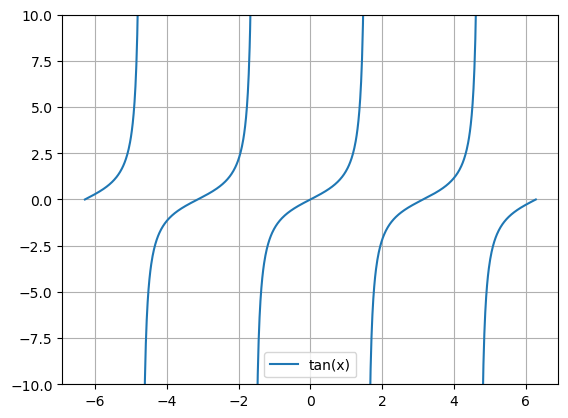

In [39]:
x = np.linspace(-2 * np.pi, 2 * np.pi, 1000)
y = np.tan(x)

mi_plot(x, y, gap=10, label="tan(x)")
plt.ylim(-10, 10)
plt.show()

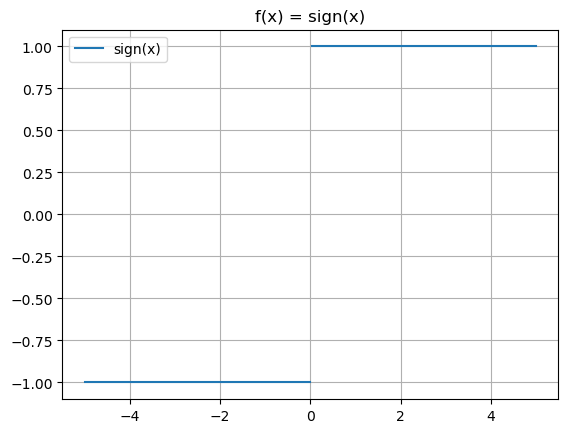

In [30]:
x = np.linspace(-5, 5, 500)
y = np.sign(x)

mi_plot(x, y, gap=1, label="sign(x)")
plt.title("f(x) = sign(x)")
plt.show()

2. Se tiene la siguiente función definida en el intervalo $[0,1]$:
$$
f(x)= \left\{ \begin{matrix}
{\rm Ai}(10x + ai_0 ) \textrm{ si } |x| \leq 1 \\ 
0 \textrm{ si } |x| > 1 \end{matrix} 
\right.
$$
donde $Ai(x)$ es la función de Airy, y $ai_0$ es la raíz de dicha función más cercana al cero. Defina una funcion $g(x)$ como la repetición periódica de dicha función para $x\in \mathbb{R}$. Verifique el resultado haciendo la gráfica de dicha función en el intervalo $[-10,10]$ o cualquier otro intervalo cuyo dominio sea mayor.

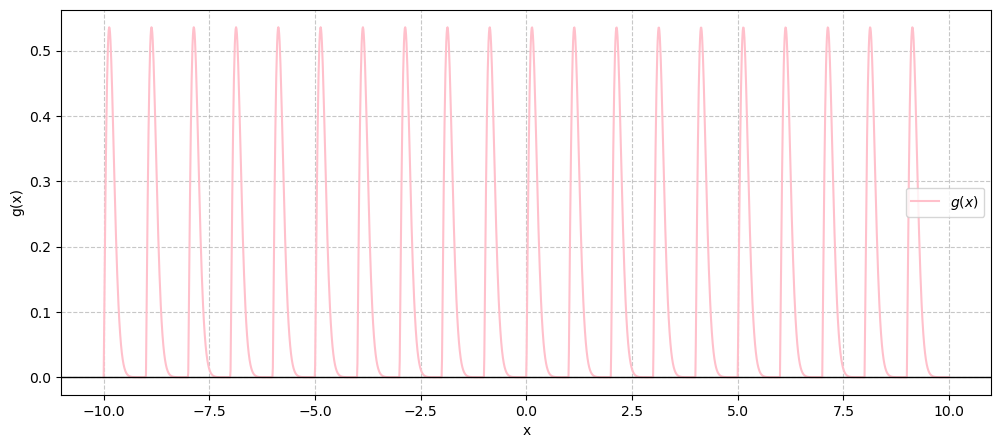

In [23]:
from scipy.special import airy, ai_zeros

raices_ai, _, _, _ = ai_zeros(1)
ai0 = raices_ai[0]

def f(x):
    res = np.zeros_like(x)
    mask = (x >= 0) & (x <= 1)
    
    ai_val, _, _, _ = airy(10 * x[mask] + ai0)
    res[mask] = ai_val
    return res

def g(x):
    return f(np.mod(x, 1))

x_vals = np.linspace(-10, 10, 2000)
y_vals = g(x_vals)

plt.figure(figsize=(12, 5))
plt.plot(x_vals, y_vals, label='$g(x)$', color='pink')
plt.xlabel('x')
plt.ylabel('g(x)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.axhline(0, color='black', lw=1)
plt.legend()
plt.show()

3. Dibuje la primera y segunda derivada de la función $g(x)$ del problema anterior en el intervalo $x \in [-10,10]$. 

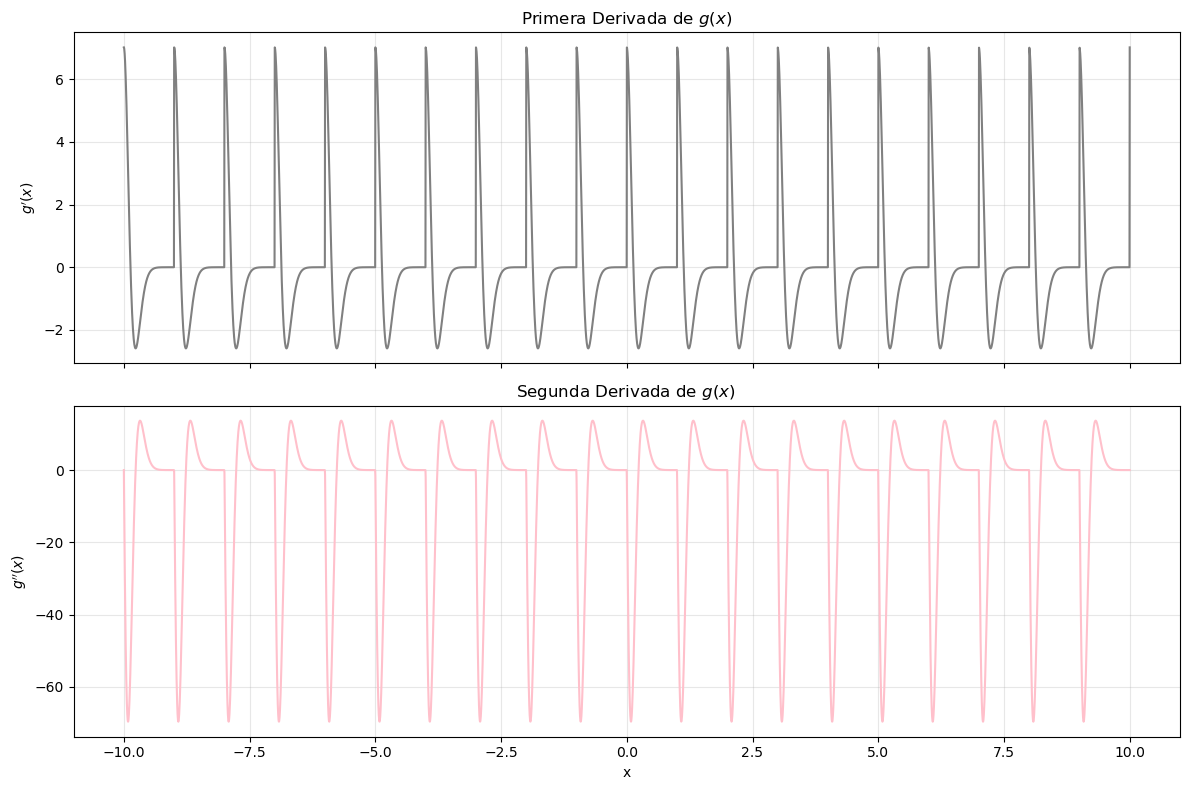

In [36]:
raices_ai, _, _, _ = ai_zeros(1)
ai0 = raices_ai[0]

def calcular_airy_y_derivadas(x_segmento):
    ai, aip, _, _ = airy(10 * x_segmento + ai0)
    
    f = ai
    f_prime = 10 * aip
    f_double_prime = 100 * (10 * x_segmento + ai0) * ai
    
    return f, f_prime, f_double_prime

x_total = np.linspace(-10, 10, 5000)
x_mod = x_total % 1

y_vals, y_prime_vals, y_double_prime_vals = calcular_airy_y_derivadas(x_mod)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

ax1.plot(x_total, y_prime_vals, color='grey', lw=1.5)
ax1.set_title("Primera Derivada de $g(x)$")
ax1.grid(True, alpha=0.3)
ax1.set_ylabel("$g'(x)$")

ax2.plot(x_total, y_double_prime_vals, color='pink', lw=1.5)
ax2.set_title("Segunda Derivada de $g(x)$ ")
ax2.set_xlabel("x")
ax2.set_ylabel("$g''(x)$")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

4. Considere la siguiente suma:
$$
a = 1 + \frac{1}{2+ \frac{1}{2+ \frac{1}{2+ \frac{1}{2+ ...}}}}
$$
Para hacer esta suma, vea lo que sucede con la suma a cada paso. Por ejemplo:

* Paso 1: $a = 1 + \frac{1}{2}$

* Paso 2: $a = 1 + \frac{1}{2+ \frac{1}{2}}$

* Paso 3: $a = 1 + \frac{1}{2+ \frac{1}{2+ \frac{1}{2}}}$

Haga una función que calcule la suma para $N$ pasos. Haga la gráfica de la convergencia de la suma anterior, es decir, la gráfica que tenga en el eje $x$ los pasos y en el eje $y$ el valor de la suma. ¿Cómo se compara la suma con el valor de $\sqrt{2}$? y ¿Cuántos términos se tienen que tomar para que las variaciones en la suma sean menores a $1 \times 10^{-6}$?

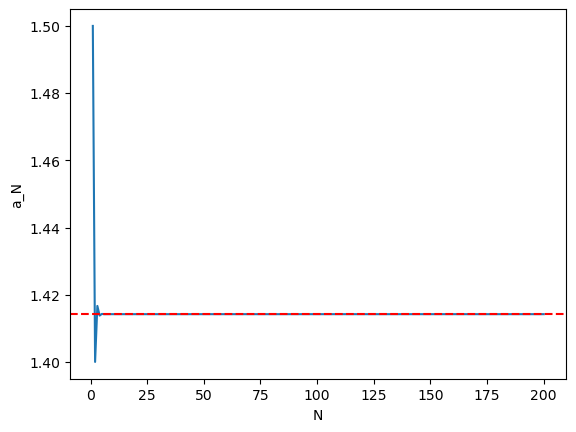

Pasos necesarios: 9


In [42]:
def continued_fraction(N):
    x = 2.0
    for _ in range(N - 1):
        x = 2.0 + 1.0/x
    return 1.0 + 1.0/x

Nmax = 200
N_values = np.arange(1, Nmax + 1)
a_values = np.array([continued_fraction(N) for N in N_values])

sqrt2 = np.sqrt(2)

steps_needed = None
for i in range(1, Nmax):
    if abs(a_values[i] - a_values[i - 1]) < 1e-6:
        steps_needed = i + 1
        break

plt.plot(N_values, a_values)
plt.axhline(sqrt2, color='red', linestyle='--')
plt.xlabel("N")
plt.ylabel("a_N")
plt.show()

print("Pasos necesarios:", steps_needed)